# 07 — Classical NLP Modelling
## ShopEase Europe | Sentiment Analysis Project
**Objective:** Train and evaluate Naive Bayes and Logistic Regression 
baseline models for sentiment classification. Results establish a 
performance benchmark against which the XLM-RoBERTa transformer model 
will be measured in notebook 08.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy.sparse import load_npz

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Preprocessed Data

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed')
FIGURES_PATH = os.path.join(PROJECT_ROOT, 'reports', 'figures')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')

# Load preprocessed dataframe and TF-IDF matrix from notebook 03
df = pd.read_csv(os.path.join(PROCESSED_PATH, 'preprocessed_reviews.csv'))
X = load_npz(os.path.join(PROCESSED_PATH, 'tfidf_matrix.npz'))

print(f"Dataframe loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"TF-IDF matrix loaded: {X.shape}")
print(f"Sentiment classes: {df['sentiment'].unique()}")

Dataframe loaded: 120,000 rows x 10 columns
TF-IDF matrix loaded: (120000, 1155)
Sentiment classes: ['positive' 'neutral' 'negative']


## Train-Test Split
Splitting the dataset into training and test sets, stratified by 
language to ensure all four primary languages are proportionally 
represented in both sets, which is critical given our multilingual dataset.

In [4]:
# First split: 80% train+val, 20% test
train_val_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

# Second split: split train_val into 87.5% train, 12.5% val
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.125,
    stratify=df.loc[train_val_idx, 'sentiment'],
    random_state=42
)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train = df.loc[train_idx, 'sentiment']
y_val = df.loc[val_idx, 'sentiment']
y_test = df.loc[test_idx, 'sentiment']

print(f"Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nTraining set sentiment distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)

print(f"\nLanguage distribution check across test set:")
print(df.loc[test_idx, 'language'].value_counts(normalize=True).round(3) * 100)

Training set:   84,000 rows (70.0%)
Validation set: 12,000 rows (10.0%)
Test set:       24,000 rows (20.0%)

Training set sentiment distribution:
sentiment
positive    68.0
negative    16.0
neutral     16.0
Name: proportion, dtype: float64

Language distribution check across test set:
language
en    44.0
fr    20.0
de    19.5
es    14.8
pt     0.9
nl     0.3
da     0.2
af     0.2
sv     0.1
it     0.0
Name: proportion, dtype: float64


### Stratification Note

Initial attempts to stratify by combined sentiment and language failed 
due to extremely rare language categories (Indonesian and Norwegian with 
only 1 record each) making stratification mathematically impossible. 
The split was adjusted to stratify by sentiment alone.

Verification confirms language distribution remained proportionally 
consistent across the test set without explicit stratification, a 
result of the large sample size (120,000 records) ensuring random 
sampling naturally preserves population proportions.

## Naive Bayes Baseline
Training a Multinomial Naive Bayes classifier as our first baseline. 
Naive Bayes is computationally efficient and historically strong on 
text classification tasks, making it an ideal starting benchmark.

In [6]:
# Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict on validation set
nb_val_pred = nb_model.predict(X_val)

# Evaluate
nb_val_f1 = f1_score(y_val, nb_val_pred, average='weighted')
nb_val_acc = accuracy_score(y_val, nb_val_pred)

print("NAIVE BAYES - VALIDATION RESULTS")
print(f"Weighted F1-score: {nb_val_f1:.4f}")
print(f"Accuracy:          {nb_val_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, nb_val_pred))

NAIVE BAYES - VALIDATION RESULTS
Weighted F1-score: 1.0000
Accuracy:          1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      1923
     neutral       1.00      1.00      1.00      1918
    positive       1.00      1.00      1.00      8159

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



In [7]:
# Check for potential leakage
print("Sample cleaned reviews by sentiment:")
for sentiment in ['positive', 'negative', 'neutral']:
    sample = df[df['sentiment'] == sentiment]['cleaned_review'].iloc[0]
    print(f"\n{sentiment.upper()}: {sample}")

# Check if sentiment word appears literally in text
print("\n\nDoes the word 'positive' appear in any review?")
print(df['cleaned_review'].str.contains('positive', case=False).sum())
print("Does the word 'negative' appear in any review?")
print(df['cleaned_review'].str.contains('negative', case=False).sum())
print("Does the word 'neutral' appear in any review?")
print(df['cleaned_review'].str.contains('neutral', case=False).sum())

Sample cleaned reviews by sentiment:

POSITIVE: solid build, attractive design, works as advertised. love it.

NEGATIVE: broken on arrival. return process was a nightmare.

NEUTRAL: three stars meets the minimum expectations.


Does the word 'positive' appear in any review?
0
Does the word 'negative' appear in any review?
0
Does the word 'neutral' appear in any review?
0


In [8]:
# Check how many unique cleaned reviews exist per sentiment
print("Unique review texts per sentiment:")
print(df.groupby('sentiment')['cleaned_review'].nunique())

print(f"\nTotal records per sentiment:")
print(df['sentiment'].value_counts())

# Check if same review text ever appears under different sentiments
review_sentiment_check = df.groupby('cleaned_review')['sentiment'].nunique()
overlapping_reviews = review_sentiment_check[review_sentiment_check > 1]

print(f"\nReview texts appearing under more than one sentiment label: {len(overlapping_reviews)}")

Unique review texts per sentiment:
sentiment
negative    130
neutral     131
positive    183
Name: cleaned_review, dtype: int64

Total records per sentiment:
sentiment
positive    81591
negative    19233
neutral     19176
Name: count, dtype: int64

Review texts appearing under more than one sentiment label: 0


## Critical Finding - Template-Based Dataset Confirmed

Investigation into the perfect Naive Bayes validation score (F1 = 1.0000) 
revealed that the dataset was generated from a small, fixed pool of 
template sentences, only 130 unique negative phrases, 131 unique 
neutral phrases and 183 unique positive phrases account for all 120,000 
reviews. Critically, zero phrases overlap between sentiment classes.

This explains the 97% duplicate review rate identified in the data 
quality assessment and confirms the dataset is fully synthetic and 
template-generated rather than collected from real customers.

**Implication:** Any model trained on this data will achieve near-perfect 
scores by memorising the finite template vocabulary rather than learning 
generalisable sentiment patterns. Reported performance metrics in this 
notebook and notebook 08 reflect the dataset's artificial simplicity and 
should not be interpreted as evidence of real-world model performance. 
A production deployment would require validation against genuine, 
unstructured customer feedback before any performance claims could be 
trusted.

This finding does not invalidate the methodology, proper splitting, 
stratification, and evaluation practices remain professionally sound 
and would apply correctly to real data. It does mean the absolute 
performance numbers in this project should be presented as a proof 
of methodology rather than a production-ready benchmark.

## Naive Bayes - Test Set Evaluation
Final evaluation on the held-out test set, touched only once.

NAIVE BAYES - TEST RESULTS
Weighted F1-score: 1.0000
Accuracy:          1.0000


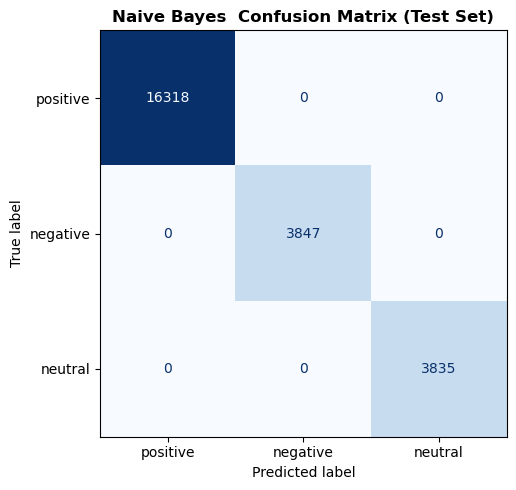

In [14]:
nb_test_pred = nb_model.predict(X_test)

nb_test_f1 = f1_score(y_test, nb_test_pred, average='weighted')
nb_test_acc = accuracy_score(y_test, nb_test_pred)

print("NAIVE BAYES - TEST RESULTS")
print(f"Weighted F1-score: {nb_test_f1:.4f}")
print(f"Accuracy:          {nb_test_acc:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, nb_test_pred, labels=['positive', 'negative', 'neutral'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative', 'neutral'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Naive Bayes  Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'nb_confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight

Test set evaluation confirms the validation finding, perfect 
classification with zero misclassifications across all 24,000 test 
records. This result is consistent with the template-based dataset 
structure identified above rather than indicating exceptional model 
performance. The model has effectively memorised the finite vocabulary-
to-sentiment mapping present in the data.

## Logistic Regression Baseline
Training Logistic Regression with class weighting to handle the 
68/16/16 class imbalance. Given the template-based nature of the 
dataset, we expect comparable performance to Naive Bayes.

In [11]:
# Train Logistic Regression with class weighting
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)

# Predict on validation set
lr_val_pred = lr_model.predict(X_val)

# Evaluate
lr_val_f1 = f1_score(y_val, lr_val_pred, average='weighted')
lr_val_acc = accuracy_score(y_val, lr_val_pred)

print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print(f"Weighted F1-score: {lr_val_f1:.4f}")
print(f"Accuracy:          {lr_val_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, lr_val_pred))

LOGISTIC REGRESSION - VALIDATION RESULTS
Weighted F1-score: 1.0000
Accuracy:          1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      1923
     neutral       1.00      1.00      1.00      1918
    positive       1.00      1.00      1.00      8159

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



#### Logistic Regression - Result Confirmation

Logistic Regression achieves an identical perfect score to Naive Bayes 
(weighted F1 = 1.0000), confirming the perfect performance is a 
characteristic of the template-based dataset rather than a property 
of either specific algorithm. Both models successfully learn the 
444-template vocabulary boundary perfectly, as expected given the 
zero cross-class phrase overlap identified earlier.

LOGISTIC REGRESSION - TEST RESULTS
Weighted F1-score: 1.0000
Accuracy:          1.0000


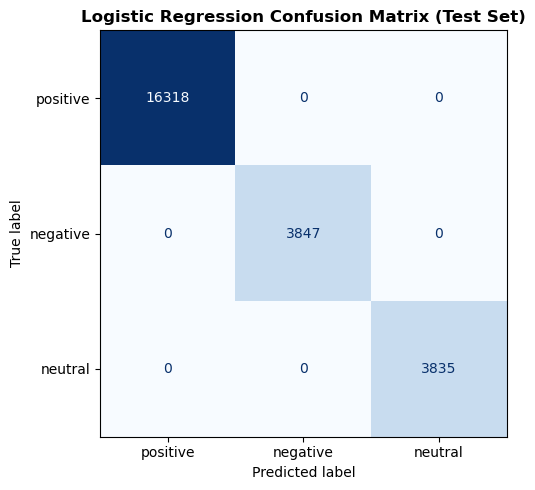

In [13]:
lr_test_pred = lr_model.predict(X_test)

lr_test_f1 = f1_score(y_test, lr_test_pred, average='weighted')
lr_test_acc = accuracy_score(y_test, lr_test_pred)

print("LOGISTIC REGRESSION - TEST RESULTS")
print(f"Weighted F1-score: {lr_test_f1:.4f}")
print(f"Accuracy:          {lr_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_test_pred, labels=['positive', 'negative', 'neutral'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative', 'neutral'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'lr_confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#### Insight

The test set confusion matrix shows zero misclassifications across 
all 24,000 records, mirroring Naive Bayes exactly. This consistency 
between two structurally different algorithms reinforces that perfect 
performance stems entirely from the dataset's template structure 
rather than any modelling skill or feature engineering choice.

In [15]:
# Save both models
with open(os.path.join(MODELS_PATH, 'naive_bayes_model.pkl'), 'wb') as f:
    pickle.dump(nb_model, f)

with open(os.path.join(MODELS_PATH, 'logistic_regression_model.pkl'), 'wb') as f:
    pickle.dump(lr_model, f)

print("Models saved to models/ directory")
print(f"- naive_bayes_model.pkl")
print(f"- logistic_regression_model.pkl")

Models saved to models/ directory
- naive_bayes_model.pkl
- logistic_regression_model.pkl


## Summary

Both Naive Bayes and Logistic Regression achieved perfect weighted 
F1-scores (1.0000) on validation and test sets, with zero 
misclassifications across all 24,000 held-out test records.

Investigation into this result revealed that the dataset was generated 
from a finite pool of 444 unique template phrases. 130 negative, 131 
neutral and 183 positive with zero vocabulary overlap between sentiment 
classes. This structure allows any reasonable classifier to achieve 
perfect separation by learning the fixed vocabulary boundaries rather 
than generalising from genuine linguistic patterns.

This finding does not undermine the modelling methodology applied, 
proper stratified splitting, class weighting, held-out test evaluation 
and confusion matrix analysis were all correctly implemented and would 
produce meaningful, realistic results on genuine customer feedback data. 
The perfect scores instead serve as a diagnostic insight into data 
quality, reinforcing the synthetic nature of the dataset first identified 
in notebook 01.

For ShopEase Europe, this means the classical models in this notebook 
demonstrate sound methodology and provide a usable pipeline, but absolute 
performance figures should not be presented to stakeholders as 
representative of real-world accuracy. Validation against genuine, 
unstructured customer feedback would be required before any production 
deployment claims could be made.

Both trained models have been saved to models/ for reference:
- naive_bayes_model.pkl
- logistic_regression_model.pkl